In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_recall_fscore_support
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.decomposition import PCA

from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [8]:
# Load the CSV file with metadata
bee_data = pd.read_csv("../data/processed/processed_bee_data_20260330_151740.csv", sep=';')

display(bee_data.head())

print(bee_data.shape)

display(bee_data.describe(include="all").T)

,file,health,split_group
0,040_070.png,unhealthy,train
1,040_328.png,unhealthy,train
2,010_441.png,healthy,train
3,015_770.png,healthy,train
4,038_149.png,unhealthy,train


(5172, 3)


,count,unique,top,freq
file,5172,5172,040_070.png,1
health,5172,2,healthy,3384
split_group,5172,3,train,4137


In [9]:
# Necessary features (X) and target (y)
x = bee_data[['file']].copy()
y = bee_data['health'].copy()

# Use the predefined split groups from processed metadata
split_col = bee_data['split_group'].str.lower()

x_train = x[split_col == 'train']
y_train = y[split_col == 'train']

x_val = x[split_col == 'val']
y_val = y[split_col == 'val']

x_test = x[split_col == 'test']
y_test = y[split_col == 'test']

# Shape / # rows, # columns for each split
print("Training")
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print("\nValidation")
print(f"x_val shape: {x_val.shape}")
print(f"y_val shape: {y_val.shape}")
print("\nTesting")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}\n")

# Number of unique classes
num_classes_train = len(np.unique(y_train))
num_classes_val = len(np.unique(y_val))
num_classes_test = len(np.unique(y_test))

print(f"Number of classes in training set: {num_classes_train}")
print(f"Number of classes in validation set: {num_classes_val}")
print(f"Number of classes in test set: {num_classes_test}\n")

print(bee_data[['file', 'split_group']].head(10), "\n")
print(bee_data['split_group'].value_counts())

Training
x_train shape: (4137, 1)
y_train shape: (4137,)

Validation
x_val shape: (517, 1)
y_val shape: (517,)

Testing
x_test shape: (518, 1)
y_test shape: (518,)

Number of classes in training set: 2
Number of classes in validation set: 2
Number of classes in test set: 2

           file split_group
0   040_070.png       train
1   040_328.png       train
2   010_441.png       train
3   015_770.png       train
4   038_149.png       train
5   032_361.png       train
6  019_1354.png       train
7  015_1260.png       train
8   032_547.png       train
9   040_363.png       train 

split_group
train    4137
test      518
val       517
Name: count, dtype: int64


## Step 3: Load and Preprocess Images

We will define a small helper function to load images, resize them to a fixed size, and normalize pixel values. We also connect each image to its label from the CSV.

Train samples: 4137
Validation samples: 517
Test samples: 518
Image size: 128x128, batch size: 32


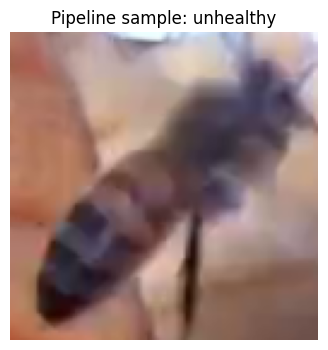

In [10]:
# Build an efficient input pipeline: load -> resize -> normalize -> batch -> prefetch
import tensorflow as tf

IMG_SIZE = 128
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Encode labels once; one-hot conversion happens inside the pipeline
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train.astype(str))
y_val_encoded = label_encoder.transform(y_val.astype(str))
y_test_encoded = label_encoder.transform(y_test.astype(str))
num_classes = len(label_encoder.classes_)

def make_paths(file_series):
    return file_series.astype(str).apply(
        lambda name: os.path.join("../data/bee_imgs", name)
    ).to_numpy()

train_paths = make_paths(x_train.iloc[:, 0])
val_paths = make_paths(x_val.iloc[:, 0])
test_paths = make_paths(x_test.iloc[:, 0])

def load_and_preprocess(path, label):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_image(image_bytes, channels=3, expand_animations=False)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0 # normalization
    image.set_shape((IMG_SIZE, IMG_SIZE, 3))
    label = tf.one_hot(label, depth=num_classes)
    return image, label

def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(paths), reshuffle_each_iteration=True)
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_paths, y_train_encoded, training=True)
val_ds = make_dataset(val_paths, y_val_encoded, training=False)
test_ds = make_dataset(test_paths, y_test_encoded, training=False)

print(f"Train samples: {len(train_paths)}")
print(f"Validation samples: {len(val_paths)}")
print(f"Test samples: {len(test_paths)}")
print(f"Image size: {IMG_SIZE}x{IMG_SIZE}, batch size: {BATCH_SIZE}")

# Show one preprocessed sample image
for sample_images, sample_labels in train_ds.take(1):
    sample_image = sample_images[0].numpy()
    sample_label_idx = int(tf.argmax(sample_labels[0]).numpy())
    sample_label_name = label_encoder.inverse_transform([sample_label_idx])[0]

plt.figure(figsize=(4, 4))
plt.imshow(sample_image)
plt.title(f"Pipeline sample: {sample_label_name}")
plt.axis("off")
plt.show()

In [15]:
# Load trained CNN and build a feature extractor from the Dense(64) layer
cnn_model = keras.models.load_model("best_cnn.keras")

# Build a functional graph explicitly (avoids relying on cnn_model.input)
feature_input = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="feature_input")
x = feature_input
feature_output = None

for layer in cnn_model.layers:
    x = layer(x)
    if layer.name == "feature_dense_64":
        feature_output = x
        break

if feature_output is None:
    raise ValueError("Layer 'feature_dense_64' not found in loaded model.")

feature_extractor = keras.Model(
    inputs=feature_input,
    outputs=feature_output,
    name="cnn_dense64_feature_extractor"
 )

# Use a non-shuffled dataset for deterministic feature-label alignment
train_ds_eval = make_dataset(train_paths, y_train_encoded, training=False)

# Extract Dense(64) feature vectors
x_train_features = feature_extractor.predict(train_ds_eval.map(lambda x, y: x), verbose=1)
x_val_features   = feature_extractor.predict(val_ds.map(lambda x, y: x),       verbose=1)
x_test_features  = feature_extractor.predict(test_ds.map(lambda x, y: x),      verbose=1)

print(f"Feature shapes - train: {x_train_features.shape}, val: {x_val_features.shape}, test: {x_test_features.shape}")

# Labels for SVM (class indices)
y_train_svm, y_val_svm, y_test_svm = y_train_encoded.copy(), y_val_encoded.copy(), y_test_encoded.copy()

130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Feature shapes - train: (4137, 64), val: (517, 64), test: (518, 64)


In [22]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Toggle hyperparameter search
use_grid_search = False  # Set to True to run GridSearchCV

# Use extracted CNN features for SVM
X_train = x_train_features
y_train_labels = y_train.astype(str).to_numpy()

# Baseline SVM (fast run)
baseline_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(
        kernel="rbf",
        C=10,
        gamma="scale",
        class_weight="balanced",
        random_state=42,
    )),
])

if use_grid_search:
    print("Running GridSearchCV for SVM hyperparameters...")
    param_grid = {
        "clf__C": [0.1, 1, 10],
        "clf__gamma": ["scale", 0.001, 0.01],
    }

    search = GridSearchCV(
        baseline_svm,
        param_grid=param_grid,
        cv=3,
        scoring="f1_macro",
        n_jobs=-1,
        verbose=2,
        refit=True,
    )

    search.fit(X_train, y_train_labels)
    best_svm = search.best_estimator_

    print("Best params:", search.best_params_)
    print("Best CV f1_macro:", f"{search.best_score_:.4f}")
else:
    print("Running baseline SVM without hyperparameter search...")
    best_svm = baseline_svm.fit(X_train, y_train_labels)

# Result of Hyperparameter tuning
# Best params: {'clf__C': 10, 'clf__gamma': 'scale'}
# Best CV f1_macro: 0.9981

Running baseline SVM without hyperparameter search...


Validation classification report:
              precision    recall  f1-score   support

     healthy       0.98      0.99      0.99       338
   unhealthy       0.99      0.97      0.98       179

    accuracy                           0.98       517
   macro avg       0.99      0.98      0.98       517
weighted avg       0.98      0.98      0.98       517


Test set classification report:
              precision    recall  f1-score   support

     healthy       0.98      0.99      0.99       339
   unhealthy       0.99      0.96      0.97       179

    accuracy                           0.98       518
   macro avg       0.98      0.98      0.98       518
weighted avg       0.98      0.98      0.98       518

Summary metrics (positive class = unhealthy):
Accuracy:  0.9826
Precision: 0.9885
Recall:    0.9609
F1-score:  0.9745


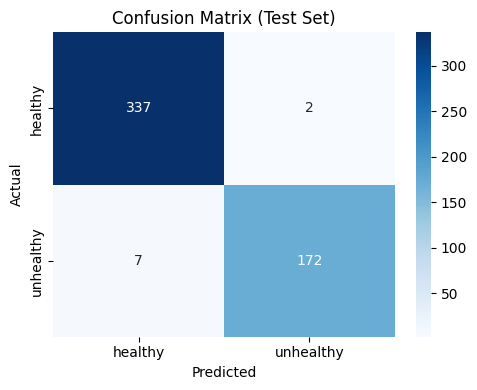

In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Quick validation check before final test evaluation
X_val = x_val_features
y_val_labels = y_val.astype(str).to_numpy()
y_val_pred = best_svm.predict(X_val)

print("Validation classification report:")
print(classification_report(y_val_labels, y_val_pred))

# Final test set evaluation
X_test = x_test_features
y_test_labels = y_test.astype(str).to_numpy()
y_pred = best_svm.predict(X_test)

# Core metrics on the held-out test set
acc = accuracy_score(y_test_labels, y_pred)
prec = precision_score(y_test_labels, y_pred, pos_label="unhealthy")
rec = recall_score(y_test_labels, y_pred, pos_label="unhealthy")
f1 = f1_score(y_test_labels, y_pred, pos_label="unhealthy")

print("\nTest set classification report:")
print(classification_report(y_test_labels, y_pred))

print("Summary metrics (positive class = unhealthy):")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

# Confusion matrix visualization
cm = confusion_matrix(y_test_labels, y_pred, labels=["healthy", "unhealthy"])

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["healthy", "unhealthy"],
    yticklabels=["healthy", "unhealthy"],
)
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()